In [2]:
import pandas as pd

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df["brand"] = df["name"].str.split().str[0]


In [4]:
df = df.drop(columns=["name"])


In [5]:
df["age"] = 2025 - df["year"]
df = df.drop(columns=["year"])


In [6]:
df = pd.get_dummies(df, columns=["fuel", "seller_type", "transmission", "owner", "brand"], drop_first=True)


In [7]:
X = df.drop(columns=["selling_price"])
y = df["selling_price"]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(184882.00841704704, np.float64(378760.3688532229), 0.529903717513045)

In [27]:
import pandas as pd

df_raw = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")  # path'ini senin ortama göre yaz


In [28]:
df_raw["model_family"] = df_raw["name"].apply(lambda x: " ".join(str(x).split()[:2]))


In [29]:
df["model_family"] = df_raw["model_family"]


In [30]:
df = pd.get_dummies(df, columns=["model_family"], drop_first=True)


In [33]:
df["age"] = 2025 - df["year"]
df.drop(columns=["year"], inplace=True)


In [34]:
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)


Index(['fuel', 'seller_type', 'transmission', 'owner'], dtype='object')


In [35]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [36]:
X = df.drop(columns=["selling_price"])
y = df["selling_price"]


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["km_driven", "age"]  # varsa başka gerçek sayısal kolonlar ekleyebilirsin

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 124463.55873305429
RMSE: 344270.0375587741
R2  : 0.6116205798362668


In [40]:
import pandas as pd
coef = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef.head(20)


,feature,coef
126,model_family_Mercedes-Benz S-Class,7.355720e+06
123,model_family_Mercedes-Benz GLS,4.811900e+06
15,model_family_BMW X5,4.102205e+06
122,model_family_Mercedes-Benz GL-Class,3.854978e+06
4,model_family_Audi A5,3.802883e+06
187,model_family_Volvo XC,3.792529e+06
78,model_family_Land Rover,3.281458e+06
120,model_family_Mercedes-Benz C-Class,2.971030e+06
75,model_family_Jaguar XJ,2.150449e+06
8,model_family_Audi Q5,1.956494e+06


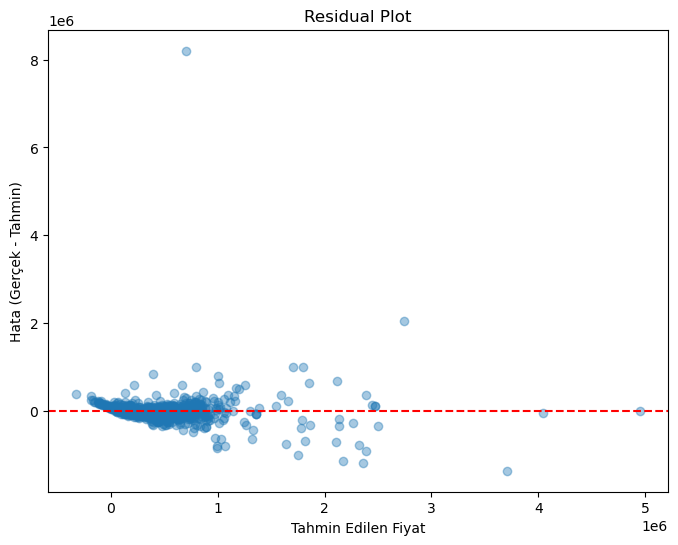

In [41]:
import matplotlib.pyplot as plt

# residuals = hata
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Tahmin Edilen Fiyat")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.title("Residual Plot")
plt.show()


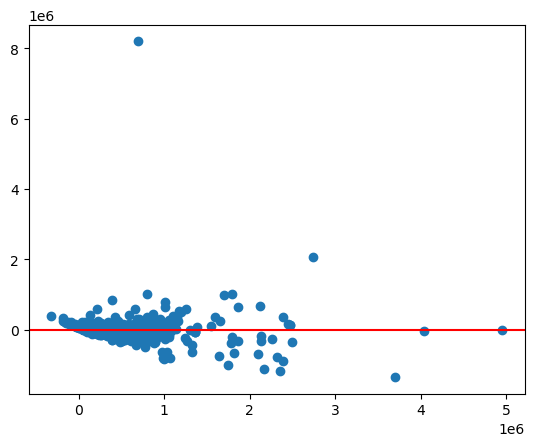

In [42]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.show()


In [43]:
import numpy as np

# y'yi log1p ile dönüştürüyoruz (log(1 + x), 0 fiyat olursa da patlamasın diye)
y_log = np.log1p(df["selling_price"])

X = df.drop(columns=["selling_price"])


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ["km_driven", "age"]  # varsa başka gerçek sayısal kolon ekleyebilirsin

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])


In [46]:
from sklearn.linear_model import LinearRegression

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

y_pred_log = model_log.predict(X_test)


In [47]:
y_test_actual = np.expm1(y_test_log)     # log1p'nin tersi
y_pred_actual = np.expm1(y_pred_log)


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 95426.04559693702
RMSE: 326172.44545007346
R2  : 0.6513800031586172


In [49]:
residuals_log = y_test_log - y_pred_log


In [52]:
residuals_log = y_test_log - y_pred_log


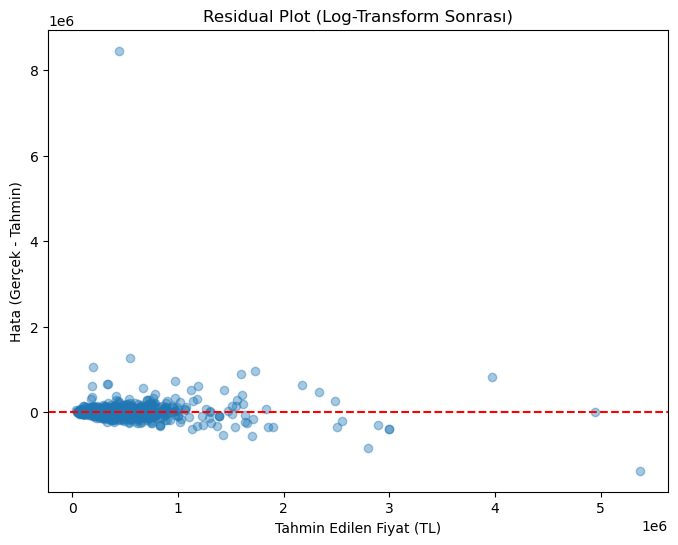

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_pred_actual, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Tahmin Edilen Fiyat (TL)")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.title("Residual Plot (Log-Transform Sonrası)")
plt.show()


In [54]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Modeli oluştur
rf = RandomForestRegressor(
    n_estimators=400,     # orman büyüklüğü
    max_depth=None,       # maksimum karmaşıklık
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1             # tüm CPU çekirdeklerini kullan
)

# Log(y) ile fit et
rf.fit(X_train, y_train_log)

# Log uzayında tahmin
y_pred_log_rf = rf.predict(X_test)

# Orijinal skala (TL) seviyesine geri çevir
y_pred_rf = np.expm1(y_pred_log_rf)
y_test_actual = np.expm1(y_test_log)


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf  = mean_absolute_error(y_test_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
r2_rf   = r2_score(y_test_actual, y_pred_rf)

print("MAE (Random Forest): ", mae_rf)
print("RMSE (Random Forest):", rmse_rf)
print("R² (Random Forest):  ", r2_rf)


MAE (Random Forest):  97110.41154061089
RMSE (Random Forest): 330226.6436281701
R² (Random Forest):   0.642659717756034


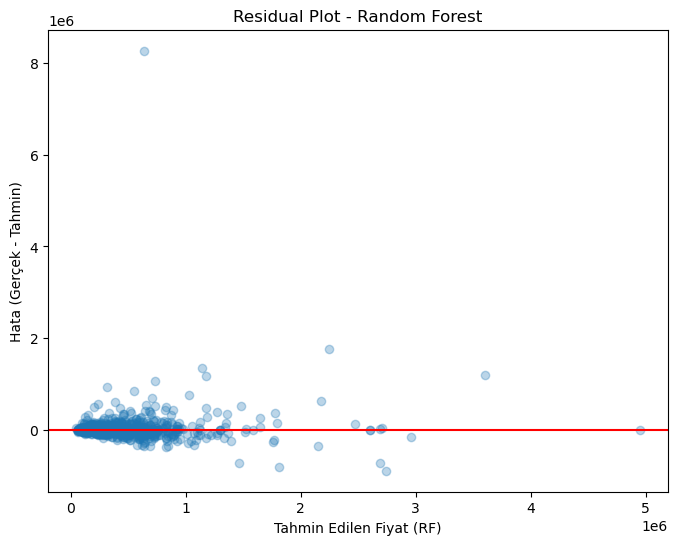

In [56]:
import matplotlib.pyplot as plt

residuals_rf = y_test_actual - y_pred_rf

plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Tahmin Edilen Fiyat (RF)")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.title("Residual Plot - Random Forest")
plt.show()


MAE : 178544.99041033108
RMSE: 408198.4997360882
R²  : 0.45399004167586043


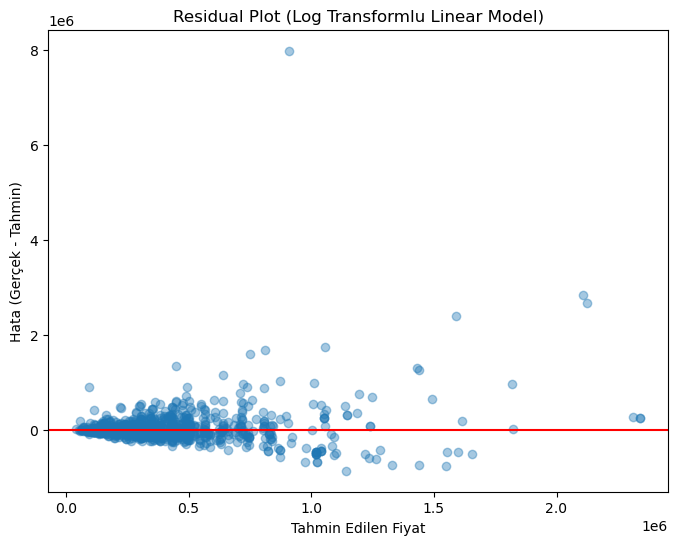

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1) DATASETİ YÜKLE
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

# 2) FEATURE ENGINEERING (SIMPLE VERSION)
df["age"] = 2025 - df["year"]
df = df.drop(columns=["year", "name"])   # name lineer modele uygun değildir

# 3) CATEGORICAL ONE-HOT
cat_cols = ["fuel", "seller_type", "transmission", "owner"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 4) X ve y tanımla
X = df.drop(columns=["selling_price"])
y = df["selling_price"]

# 5) LOG TRANSFORM TARGET
y_log = np.log1p(y)

# 6) SPLIT
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 7) SCALE ONLY NUMERIC
scaler = StandardScaler()
num_cols = ["km_driven", "age"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# 8) LINEER REGRESYON MODELİ
model = LinearRegression()
model.fit(X_train, y_train_log)

# 9) TAHMİN (log uzayında)
y_pred_log = model.predict(X_test)

# 10) GERÇEK SKALAYA GERİ DÖN
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# 11) METRİKLER
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# 12) RESIDUAL PLOT
residuals = y_test_actual - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("Tahmin Edilen Fiyat")
plt.ylabel("Hata (Gerçek - Tahmin)")
plt.title("Residual Plot (Log Transformlu Linear Model)")
plt.show()
